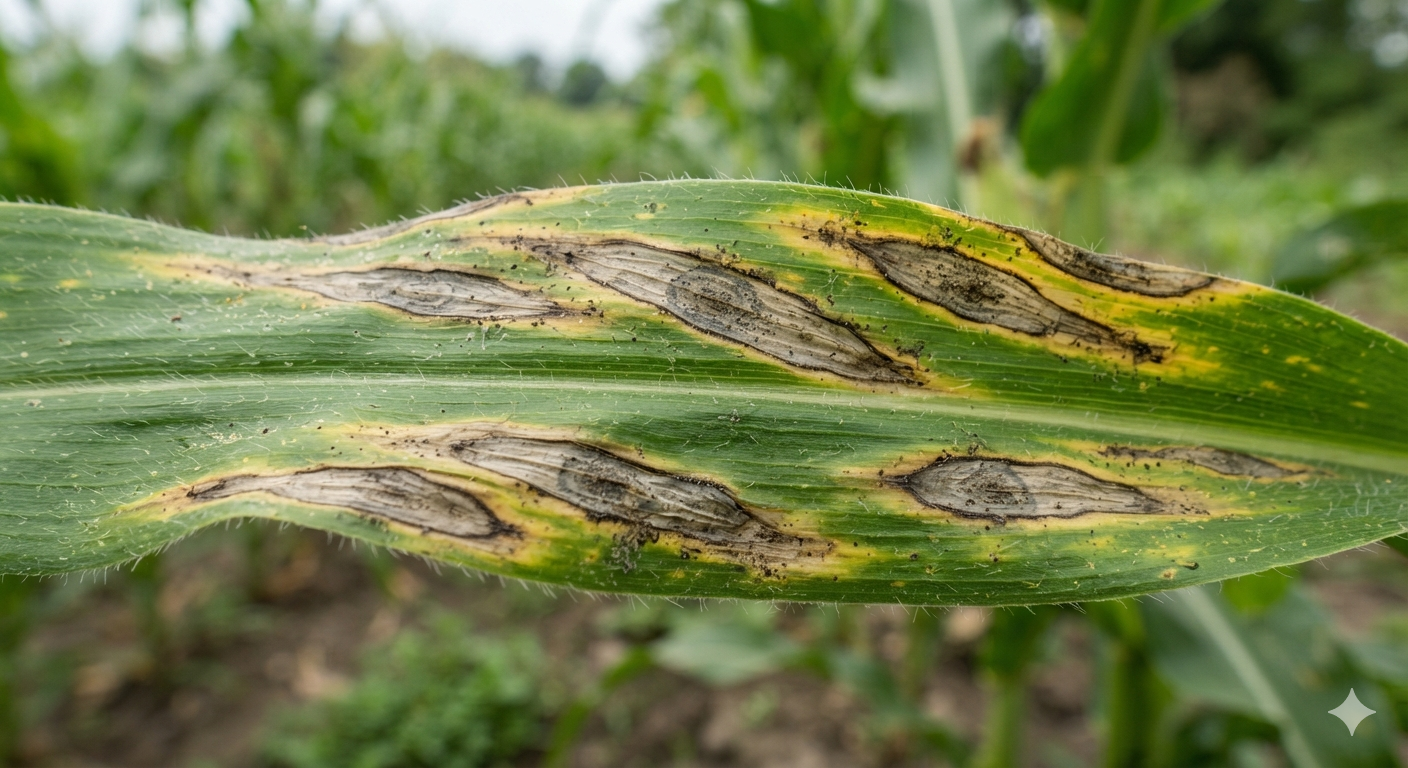


# Corn Leaf Disease Classification: CRISP-DM Plan

This notebook documents the project from business understanding through data preparation. The task is multiclass image classification with four classes: **Blight**, **Common_Rust**, **Gray_Leaf_Spot**, and **Healthy**.

Project Overview

This project develops a deep-learning image classifier for detecting corn leaf conditions: Blight, Common Rust, Gray Leaf Spot, and Healthy. Following CRISP-DM, the images are cleaned, converted to RGB, resized , and split into training and validation sets. A baseline CNN is compared with a pretrained model such as MobileNetV2 or EfficientNetB0. Performance is measured using accuracy, macro F1-score, per-class recall, precision, and a confusion matrix. The final system is designed to support farmers and agronomists with fast preliminary disease screening, while expert confirmation remains necessary.



## 1. Business Understanding

### Business problem
Corn diseases can reduce yield and quality when they are detected late. Field diagnosis may be slow, inconsistent, or dependent on access to an experienced agronomist. A computer-vision classifier can provide an early screening signal from a photograph of a corn leaf.

### Problem statement
Develop and evaluate an image-classification model that predicts the visible condition of a corn leaf as Blight, Common Rust, Gray Leaf Spot, or Healthy. The model should support rapid, repeatable screening while clearly communicating that predictions are decision support rather than a replacement for expert confirmation.

### Objectives

| Objective | Description | Deliverable |
|---|---|---|
| Classify leaf images | Predict one of four disease/health classes | Trained multiclass classifier |
| Reduce missed disease | Prioritize recall for disease classes, especially in field screening | Per-class recall and confusion matrix |
| Produce trustworthy probabilities | Return confidence scores and flag uncertain cases | Calibrated probabilities or an uncertainty threshold |
| Make the workflow reproducible | Use a documented local path, fixed seed, split, and preprocessing pipeline | Re-runnable notebook |
| Support practical use | Keep inference fast enough for an image-upload workflow | Inference-time and model-size measurements |

### Stakeholders and their interests

| Stakeholder | Interest | What success means for them |
|---|---|---|
| Farmers and field scouts | Fast, accessible disease screening | Correct early alerts and few missed diseased leaves |
| Agronomists and extension officers | A consistent second opinion | Useful explanations, confidence scores, and easy review of uncertain images |
| Agribusiness and crop advisors | Scalable crop-health monitoring | Lower inspection cost and reliable performance across farms |
| Researchers and students | Reproducible experimentation | Transparent data splits, methods, metrics, and limitations |
| Product or deployment team | Maintainable local or web inference | Stable preprocessing, acceptable latency, and versioned models |
| Crop policy and food-security planners | Early visibility of disease patterns | Aggregated, reliable signals without overstating model certainty |

### Value of automation

Automation enables rapid screening of many images, consistent application of the same decision rule, lower manual inspection effort, and earlier escalation to an expert. It is most valuable as a triage layer: high-confidence cases can be prioritized while low-confidence or unusual images are referred for human diagnosis.



## 2. Data Understanding

### Dataset profile and working assumption

| Item | Project value / assumption |
|---|---|
| Class names | Blight, Common_Rust, Gray_Leaf_Spot, Healthy |
| Original image dimensions | Audited from the files; images may have different dimensions |
| Resized dimensions | 224 x 224 pixels, RGB, for a practical transfer-learning baseline |
| Class balance | Imbalanced; Gray_Leaf_Spot is the smallest class |
| Training split | 80% of images, stratified by class |
| Validation split | 20% of images, stratified by class |
| Total source images | 4,188 in the current local dataset audit |
| Expected training images | Computed by the audit cell, approximately 3,350 |
| Expected validation images | Computed by the audit cell, approximately 838 |
| Label type | Single-label multiclass classification |
| Leakage control | Split by image before augmentation; do not place near-duplicate images in both splits |



2.1 Importing the libraries

In [19]:
#Step 1 — Import the libraries
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import os
import shutil
import hashlib
from pathlib import Path
from collections import Counter
from PIL import Image
from IPython.display import display
import tensorflow as tf
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers


2.2 . Data overview

In [2]:
# Build audit_df before running the Data Understanding cells.
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
EXPECTED_CLASSES = {"Blight", "Common_Rust", "Gray_Leaf_Spot", "Healthy"}

search_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
DATA_CANDIDATES = []
for root in search_roots:
    DATA_CANDIDATES.extend([
        root / "data",
        root / "corn_pathology_ai-main" / "corn_pathology_ai-main" / "data",
        root / "corn_pathology_ai-main" / "data",
    ])

DATA_CANDIDATES = list(dict.fromkeys(DATA_CANDIDATES))
DATA_DIR = next(
    (
        path for path in DATA_CANDIDATES
        if path.is_dir()
        and EXPECTED_CLASSES.intersection({folder.name for folder in path.iterdir() if folder.is_dir()})
    ),
    None,
)

if DATA_DIR is None:
    checked_paths = "\n".join(f"- {path}" for path in DATA_CANDIDATES)
    raise FileNotFoundError(
        "Corn dataset not found. Add the extracted dataset to a data folder "
        "with Blight, Common_Rust, Gray_Leaf_Spot, and Healthy subfolders. "
        f"Checked:\n{checked_paths}"
    )

records = []
unreadable_images = []

for class_dir in sorted(path for path in DATA_DIR.iterdir() if path.is_dir()):
    if class_dir.name not in EXPECTED_CLASSES:
        continue
    for image_path in sorted(class_dir.iterdir()):
        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue
        try:
            with Image.open(image_path) as image:
                image.verify()
            with Image.open(image_path) as image:
                records.append({
                    "path": str(image_path),
                    "class_name": class_dir.name,
                    "width": image.width,
                    "height": image.height,
                    "channels": len(image.getbands()),
                    "format": image.format,
                    "color_mode": image.mode,
                })
        except (OSError, ValueError):
            unreadable_images.append(str(image_path))

audit_df = pd.DataFrame(records)
if audit_df.empty:
    raise ValueError(f"No readable class images found under {DATA_DIR}")

class_names = sorted(audit_df["class_name"].unique())
print(f"Dataset directory: {DATA_DIR}")
print(f"Audited readable images: {len(audit_df):,}")
print(f"Unreadable images: {len(unreadable_images)}")

Dataset directory: c:\Users\admin\Downloads\corn_pathology_ai-main\corn_pathology_ai-main\data
Audited readable images: 4,188
Unreadable images: 0


In [3]:
print("Total valid images:", len(audit_df))
print("Number of classes:", audit_df["class_name"].nunique())
print("Classes:", sorted(audit_df["class_name"].unique()))

display(audit_df.head())

print("\nDataset information:")
audit_df.info()

Total valid images: 4188
Number of classes: 4
Classes: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


,path,class_name,width,height,channels,format,color_mode
0,c:\Users\admin\Downloads\corn_pathology_ai-mai...,Blight,1000,585,3,JPEG,RGB
1,c:\Users\admin\Downloads\corn_pathology_ai-mai...,Blight,788,371,3,JPEG,RGB
2,c:\Users\admin\Downloads\corn_pathology_ai-mai...,Blight,641,482,3,JPEG,RGB
3,c:\Users\admin\Downloads\corn_pathology_ai-mai...,Blight,300,200,3,JPEG,RGB
4,c:\Users\admin\Downloads\corn_pathology_ai-mai...,Blight,256,256,3,JPEG,RGB



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 4188 entries, 0 to 4187
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   path        4188 non-null   str  
 1   class_name  4188 non-null   str  
 2   width       4188 non-null   int64
 3   height      4188 non-null   int64
 4   channels    4188 non-null   int64
 5   format      4188 non-null   str  
 6   color_mode  4188 non-null   str  
dtypes: int64(3), str(4)
memory usage: 229.2 KB


2.3 Image metadata distribution

In [4]:
print("Image formats:")
display(audit_df["format"].value_counts())

print("Color modes:")
display(audit_df["color_mode"].value_counts())

print("Image dimensions:")
display(audit_df[["width", "height"]].describe())

Image formats:


format
JPEG    4183
PNG        4
MPO        1
Name: count, dtype: int64

Color modes:


color_mode
RGB     4183
RGBA       4
CMYK       1
Name: count, dtype: int64

Image dimensions:


,width,height
count,4188.000000,4188.000000
mean,307.536533,297.906160
std,285.716933,253.138674
min,180.000000,116.000000
25%,256.000000,256.000000
50%,256.000000,256.000000
75%,256.000000,256.000000
max,5184.000000,5184.000000


2.4  Check missing metadata

In [5]:
missing_values = audit_df.isnull().sum()

print("Missing values by column:")
display(missing_values)

print("Total missing values:", missing_values.sum())

Missing values by column:


path          0
class_name    0
width         0
height        0
channels      0
format        0
color_mode    0
dtype: int64

Total missing values: 0


2.5 Image metadata distribution

In [6]:
print("Image formats:")
display(audit_df["format"].value_counts())

print("Color modes:")
display(audit_df["color_mode"].value_counts())

print("Image dimensions:")
display(audit_df[["width", "height"]].describe())

Image formats:


format
JPEG    4183
PNG        4
MPO        1
Name: count, dtype: int64

Color modes:


color_mode
RGB     4183
RGBA       4
CMYK       1
Name: count, dtype: int64

Image dimensions:


,width,height
count,4188.000000,4188.000000
mean,307.536533,297.906160
std,285.716933,253.138674
min,180.000000,116.000000
25%,256.000000,256.000000
50%,256.000000,256.000000
75%,256.000000,256.000000
max,5184.000000,5184.000000


2.6 Check image quality and file sizes

In [7]:
from pathlib import Path

quality_df = audit_df.copy()

quality_df["file_size_kb"] = quality_df["path"].apply(
    lambda path: Path(path).stat().st_size / 1024
)

quality_df["aspect_ratio"] = (
    quality_df["width"] / quality_df["height"]
)

quality_df["image_area"] = (
    quality_df["width"] * quality_df["height"]
)

display(quality_df[
    ["width", "height", "file_size_kb", "aspect_ratio", "image_area"]
].describe().round(2))

,width,height,file_size_kb,aspect_ratio,image_area
count,4188.00,4188.00,4188.00,4188.00,4188.00
mean,307.54,297.91,38.46,1.02,156855.33
std,285.72,253.14,218.26,0.16,811837.53
min,180.00,116.00,3.12,0.29,33872.00
25%,256.00,256.00,11.40,1.00,65536.00
50%,256.00,256.00,13.52,1.00,65536.00
75%,256.00,256.00,15.56,1.00,65536.00
max,5184.00,5184.00,6331.98,3.75,17915904.00


In [8]:
quality_df["file_size_kb"] = quality_df["path"].apply(
    lambda path: Path(path).stat().st_size / 1024
)

2.6.1 Check unreadable files


In [9]:
print("Unreadable images:", len(unreadable_images))

if unreadable_images:
    display(pd.DataFrame({"unreadable_filepath": unreadable_images}))
else:
    print("No unreadable images detected.")

Unreadable images: 0
No unreadable images detected.


2.7 Class balance

In [10]:
class_counts = (
    audit_df["class_name"]
    .value_counts()
    .reindex(class_names, fill_value=0)
)

class_balance_df = pd.DataFrame({
    "class": class_counts.index,
    "image_count": class_counts.values,
    "percentage": (class_counts.values / class_counts.sum() * 100).round(2)
})

display(class_balance_df)

,class,image_count,percentage
0,Blight,1146,27.36
1,Common_Rust,1306,31.18
2,Gray_Leaf_Spot,574,13.71
3,Healthy,1162,27.75


2.8  Visualize class distribution

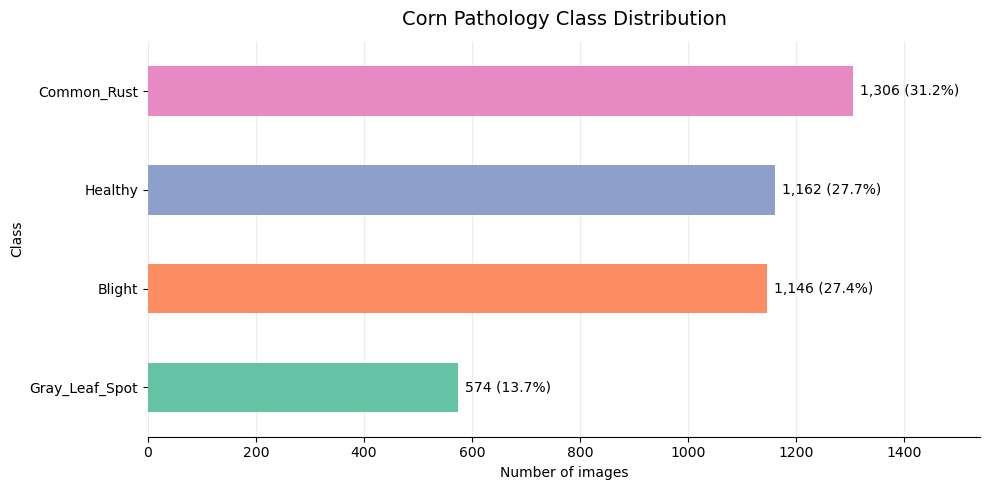

In [11]:
# Visualize class imbalance distribution
class_counts = audit_df["class_name"].value_counts().sort_values(ascending=True)
class_percentages = class_counts / class_counts.sum() * 100

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = sns.color_palette("Set2", n_colors=len(class_counts))
class_counts.plot.barh(ax=ax, color=bar_colors, edgecolor="none")

for position, (count, percentage) in enumerate(zip(class_counts, class_percentages)):
    ax.text(count + class_counts.max() * 0.01, position, f"{count:,} ({percentage:.1f}%)", va="center")

ax.set_title("Corn Pathology Class Distribution", fontsize=14, pad=12)
ax.set_xlabel("Number of images")
ax.set_ylabel("Class")
ax.set_xlim(0, class_counts.max() * 1.18)
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)
sns.despine(ax=ax, left=True, bottom=False)
plt.tight_layout()
plt.show()


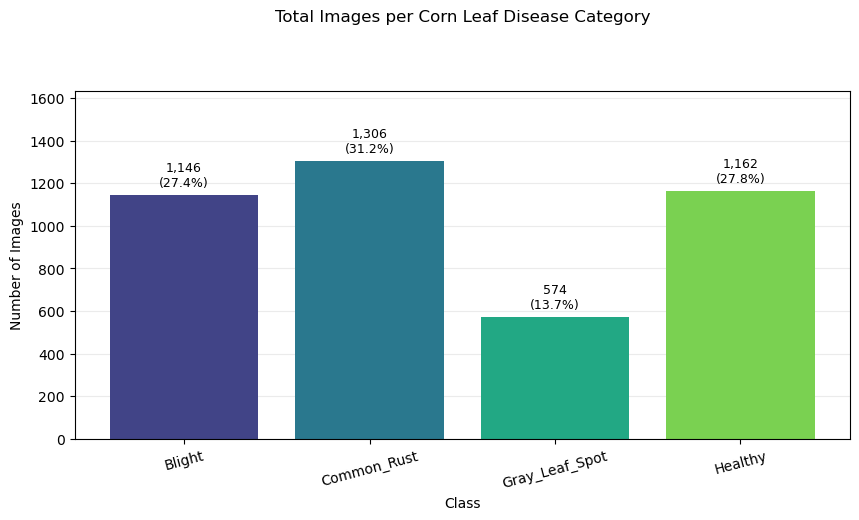

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    class_balance_df["class"],
    class_balance_df["image_count"],
    color=sns.color_palette("viridis", n_colors=len(class_balance_df)),
)

max_count = class_balance_df["image_count"].max()
label_offset = max_count * 0.02

for bar, count, percentage in zip(
    bars,
    class_balance_df["image_count"],
    class_balance_df["percentage"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        count + label_offset,
        f"{count:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_ylim(0, max_count * 1.25)
ax.set_title(
    "Total Images per Corn Leaf Disease Category",
    y=1.16,
    pad=10,
)
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

fig.subplots_adjust(top=0.76, bottom=0.18)
plt.show()

Inspect sample images

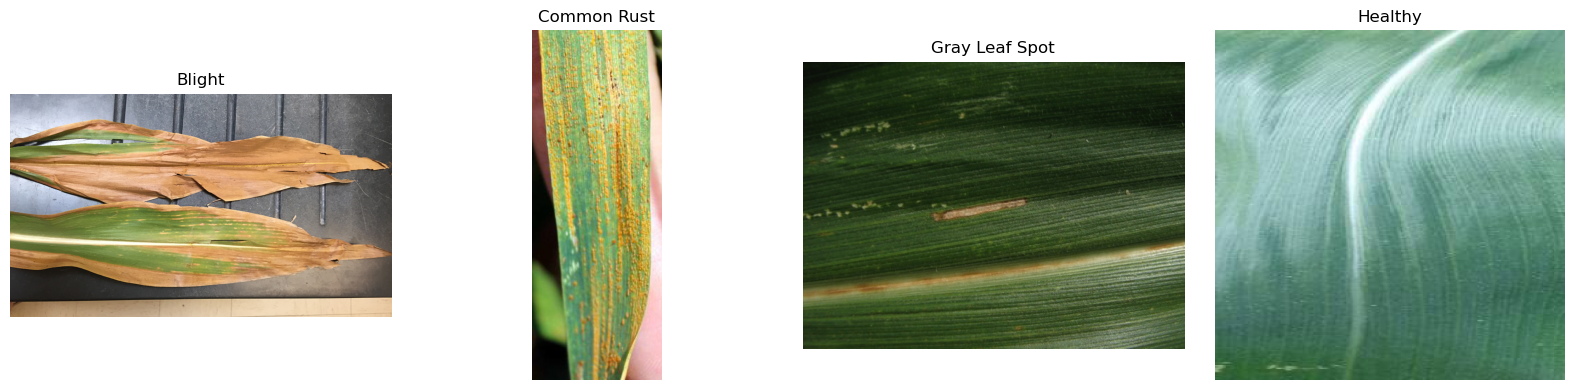

In [13]:
# Inspect one sample image from each discovered class.
class_dirs = [
    folder for folder in sorted(DATA_DIR.iterdir())
    if folder.is_dir() and folder.name in EXPECTED_CLASSES
]

fig, axes = plt.subplots(1, len(class_dirs), figsize=(4 * len(class_dirs), 4))
axes = np.atleast_1d(axes).ravel()

for axis, class_dir in zip(axes, class_dirs):
    image_paths = [
        path for path in class_dir.iterdir()
        if path.suffix.lower() in IMAGE_EXTENSIONS
    ]

    if not image_paths:
        axis.set_title(f"{class_dir.name}\nNo images found")
        axis.axis("off")
        continue

    image_path = image_paths[0]

    with Image.open(image_path) as image:
        axis.imshow(image.convert("RGB"))

    axis.set_title(class_dir.name.replace("_", " "))
    axis.axis("off")

plt.tight_layout()
plt.show()

2.9 Diagnose class imbalance

In [14]:
largest_class = class_counts.max()
smallest_class = class_counts.min()

imbalance_ratio = largest_class / smallest_class

print("Largest class:", class_counts.idxmax(), largest_class)
print("Smallest class:", class_counts.idxmin(), smallest_class)
print(f"Imbalance ratio: {imbalance_ratio:.2f}")

if imbalance_ratio > 1.5:
    print("The dataset is imbalanced. Use class weights or balanced sampling.")
else:
    print("The class distribution is relatively balanced.")

Largest class: Common_Rust 1306
Smallest class: Gray_Leaf_Spot 574
Imbalance ratio: 2.28
The dataset is imbalanced. Use class weights or balanced sampling.


2.9.1 Analyze geometric properties

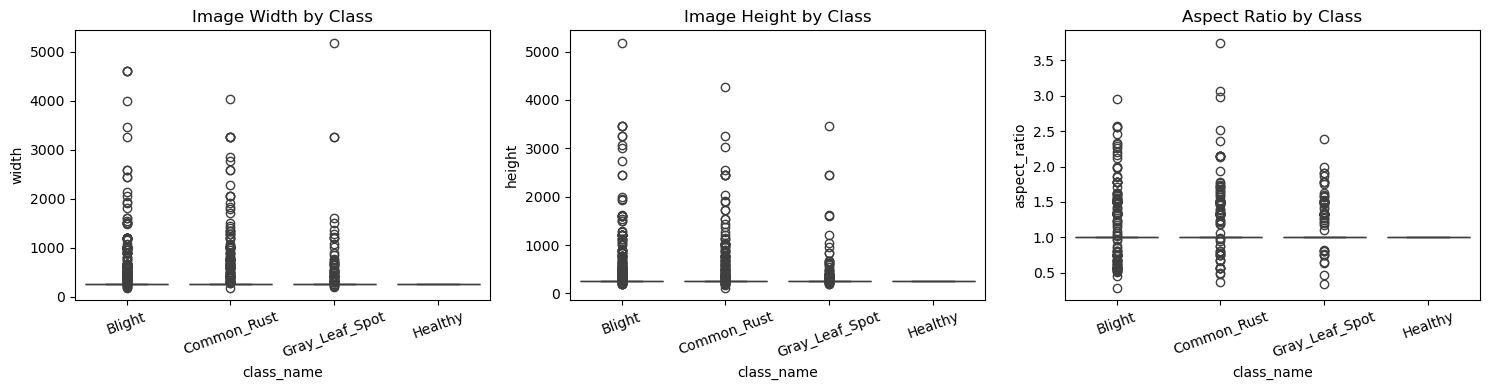

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=quality_df, x="class_name", y="width", ax=axes[0])
axes[0].set_title("Image Width by Class")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(data=quality_df, x="class_name", y="height", ax=axes[1])
axes[1].set_title("Image Height by Class")
axes[1].tick_params(axis="x", rotation=20)

sns.boxplot(data=quality_df, x="class_name", y="aspect_ratio", ax=axes[2])
axes[2].set_title("Aspect Ratio by Class")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Find unusual geometric images:

In [16]:
low_resolution_images = quality_df[
    (quality_df["width"] < 100) |
    (quality_df["height"] < 100)
]

extreme_aspect_images = quality_df[
    (quality_df["aspect_ratio"] < 0.5) |
    (quality_df["aspect_ratio"] > 2.0)
]

print("Low-resolution images:", len(low_resolution_images))
print("Extreme-aspect-ratio images:", len(extreme_aspect_images))

display(low_resolution_images.head())
display(extreme_aspect_images.head())

Low-resolution images: 0
Extreme-aspect-ratio images: 30


,path,class_name,width,height,channels,format,color_mode,file_size_kb,aspect_ratio,image_area


,path,class_name,width,height,channels,format,color_mode,file_size_kb,aspect_ratio,image_area
1,c:\Users\admin\Downloads\corn_pathology_ai-mai...,Blight,788,371,3,JPEG,RGB,76.775391,2.123989,292348
14,c:\Users\admin\Downloads\corn_pathology_ai-mai...,Blight,1080,421,3,JPEG,RGB,226.377930,2.565321,454680
25,c:\Users\admin\Downloads\corn_pathology_ai-mai...,Blight,1489,3264,3,JPEG,RGB,1113.178711,0.456189,4860096
122,c:\Users\admin\Downloads\corn_pathology_ai-mai...,Blight,884,3071,3,JPEG,RGB,379.745117,0.287854,2714764
141,c:\Users\admin\Downloads\corn_pathology_ai-mai...,Blight,896,407,3,JPEG,RGB,94.029297,2.201474,364672


2.9.2  Analyze brightness, contrast, saturation, and sharpness

In [17]:
def calculate_visual_features(image_path):
    with Image.open(image_path) as image:
        image = image.convert("RGB").resize((128, 128))

        rgb = np.asarray(image).astype("float32") / 255.0
        grayscale = np.asarray(image.convert("L")).astype("float32") / 255.0
        hsv = np.asarray(image.convert("HSV")).astype("float32") / 255.0

        horizontal_edges = np.diff(grayscale, axis=1)
        vertical_edges = np.diff(grayscale, axis=0)

        return {
            "brightness": rgb.mean(),
            "contrast": grayscale.std(),
            "saturation": hsv[:, :, 1].mean(),
            "red_mean": rgb[:, :, 0].mean(),
            "green_mean": rgb[:, :, 1].mean(),
            "blue_mean": rgb[:, :, 2].mean(),
            "sharpness_proxy": np.std(
                np.concatenate([
                    horizontal_edges.ravel(),
                    vertical_edges.ravel()
                ])
            )
        }

visual_features = []

for _, row in audit_df.iterrows():
    try:
        features = calculate_visual_features(row["path"])
        features["class_name"] = row["class_name"]
        features["path"] = row["path"]
        visual_features.append(features)
    except (OSError, ValueError):
        pass

visual_df = pd.DataFrame(visual_features)

display(
    visual_df.groupby("class_name")[
        [
            "brightness",
            "contrast",
            "saturation",
            "red_mean",
            "green_mean",
            "blue_mean",
            "sharpness_proxy"
        ]
    ].mean().round(3)
)

,brightness,contrast,saturation,red_mean,green_mean,blue_mean,sharpness_proxy
class_name,,,,,,,
Blight,0.438,0.127,0.286,0.449,0.481,0.383,0.044
Common_Rust,0.343,0.240,0.289,0.359,0.391,0.278,0.058
Gray_Leaf_Spot,0.442,0.140,0.291,0.459,0.487,0.381,0.053
Healthy,0.540,0.125,0.322,0.504,0.640,0.476,0.035


**3. DATA PREPARATION**

Transform audited images into clean, standardized, leak-free tensors for modeling.

### 3.1 Clean duplicates and encode labels

In [20]:
# Perceptual and exact duplicate cleaning
# A file hash only detects byte-for-byte copies; this pHash also catches resized/recompressed copies.
from PIL import Image, ImageOps

PHASH_SIZE = 32
PHASH_LOW_FREQUENCY_SIZE = 8
PHASH_DISTANCE_THRESHOLD = 8


def calculate_hash(path):
    with open(path, "rb") as file:
        return hashlib.sha256(file.read()).hexdigest()


def calculate_perceptual_hash(path):
    with Image.open(path) as image:
        grayscale = ImageOps.grayscale(image).resize(
            (PHASH_SIZE, PHASH_SIZE), Image.Resampling.LANCZOS
        )
    pixels = np.asarray(grayscale, dtype=np.float32)
    coordinate_range = np.arange(PHASH_SIZE, dtype=np.float32)
    frequency_range = np.arange(PHASH_SIZE, dtype=np.float32)
    basis = np.cos(
        np.pi * (2 * coordinate_range[:, None] + 1)
        * frequency_range[None, :]
        / (2 * PHASH_SIZE)
    )
    frequencies = basis.T @ pixels @ basis
    low_frequency_values = frequencies[:PHASH_LOW_FREQUENCY_SIZE, :PHASH_LOW_FREQUENCY_SIZE].flatten()
    perceptual_hash = low_frequency_values > np.median(low_frequency_values[1:])
    return perceptual_hash


def hamming_distance(left_hash, right_hash):
    return int(np.count_nonzero(left_hash != right_hash))


# Start from the audited images. Perceptual deduplication must happen before exact hashing.
source_df = audit_df.copy().reset_index(drop=True)
source_df["perceptual_hash"] = source_df["path"].apply(calculate_perceptual_hash)

# Keep the first image in each near-duplicate group. The threshold is explicit and tunable.
kept_indices = []
perceptual_group_ids = []
for row_index, perceptual_hash in enumerate(source_df["perceptual_hash"]):
    matching_group = next(
        (
            group_id
            for group_id, kept_index in enumerate(kept_indices)
            if hamming_distance(perceptual_hash, source_df.at[kept_index, "perceptual_hash"])
            <= PHASH_DISTANCE_THRESHOLD
        ),
        None,
    )
    if matching_group is None:
        kept_indices.append(row_index)
        matching_group = len(kept_indices) - 1
    perceptual_group_ids.append(matching_group)

source_df["perceptual_group"] = perceptual_group_ids
deduplicated_df = source_df.loc[kept_indices].copy().reset_index(drop=True)
perceptual_duplicates_removed = len(source_df) - len(deduplicated_df)

# Exact-hash cleaning is applied after perceptual deduplication.
prepared_df = deduplicated_df.copy()
prepared_df["image_hash"] = prepared_df["path"].apply(calculate_hash)
hash_label_counts = prepared_df.groupby("image_hash")["class_name"].nunique()
conflicting_hashes = hash_label_counts[hash_label_counts > 1].index

# Remove every row belonging to a conflicting exact-hash group.
conflicting_rows = prepared_df[prepared_df["image_hash"].isin(conflicting_hashes)]
clean_df = prepared_df[~prepared_df["image_hash"].isin(conflicting_hashes)].copy()
rows_after_conflict_removal = len(clean_df)

# Remove remaining exact duplicate files, retaining one representative per byte hash.
clean_df = clean_df.drop_duplicates(subset=["image_hash"], keep="first").copy()
exact_duplicates_removed = rows_after_conflict_removal - len(clean_df)

label_to_id = {name: index for index, name in enumerate(class_names)}
clean_df["label_id"] = clean_df["class_name"].map(label_to_id).astype("int32")

print("\n" + "=" * 60)
print("DATA CLEANING SUMMARY")
print("=" * 60)
print(f"Original audited images: {len(audit_df):,}")
print(f"After perceptual deduplication: {len(deduplicated_df):,}")
print(f"  -> Perceptual duplicates removed: {perceptual_duplicates_removed:,}")
print(f"\nBefore exact-hash cleaning: {len(prepared_df):,}")
print(f"  -> Rows removed (conflicting labels): {len(conflicting_rows):,}")
print(f"  -> Exact duplicate rows removed: {exact_duplicates_removed:,}")
print(f"After exact-hash cleaning and label encoding: {len(clean_df):,}")
print(f"  -> Total images removed: {len(audit_df) - len(clean_df):,}")
print(f"Perceptual hash threshold: {PHASH_DISTANCE_THRESHOLD} bits")
print("=" * 60)

print("\nFinal dataset by class:")
display(clean_df["class_name"].value_counts().reindex(class_names, fill_value=0))


DATA CLEANING SUMMARY
Original audited images: 4,188
After perceptual deduplication: 4,159
  -> Perceptual duplicates removed: 29

Before exact-hash cleaning: 4,159
  -> Rows removed (conflicting labels): 0
  -> Exact duplicate rows removed: 0
After exact-hash cleaning and label encoding: 4,159
  -> Total images removed: 29
Perceptual hash threshold: 8 bits

Final dataset by class:


class_name
Blight            1136
Common_Rust       1297
Gray_Leaf_Spot     570
Healthy           1156
Name: count, dtype: int64

### 3.2 Stratified splitting and leakage prevention

### 3.1.1 Reproducible split settings

These settings keep the train/validation split consistent every time the notebook runs.

In [21]:
RANDOM_STATE = 42
VALIDATION_SIZE = 0.20


In [22]:
train_df, validation_df = train_test_split(
    clean_df, test_size=VALIDATION_SIZE, random_state=RANDOM_STATE,
    stratify=clean_df["label_id"]
)

train_hashes = set(train_df["image_hash"])
validation_hashes = set(validation_df["image_hash"])
print("Exact hash overlap:", len(train_hashes & validation_hashes))

split_summary = pd.DataFrame({
    "training_images": train_df["class_name"].value_counts(),
    "validation_images": validation_df["class_name"].value_counts(),
}).reindex(class_names, fill_value=0)
display(split_summary)

Exact hash overlap: 0


,training_images,validation_images
class_name,,
Blight,909,227
Common_Rust,1037,260
Gray_Leaf_Spot,456,114
Healthy,925,231


### 3.2.1 Class weights for imbalance

Use class weights instead of oversampling first. This reduces bias toward the larger classes while keeping validation data untouched.

In [23]:
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label_id"]),
    y=train_df["label_id"]
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(np.unique(train_df["label_id"]), class_weight_values)
}

print("Class weights used during training:")
for class_name, class_id in label_to_id.items():
    print(f"{class_id} - {class_name}: {class_weights[class_id]:.3f}")


Class weights used during training:
0 - Blight: 0.915
1 - Common_Rust: 0.802
2 - Gray_Leaf_Spot: 1.824
3 - Healthy: 0.899


### 3.3 RGB conversion, aspect-ratio-preserving resize, batching, and prefetching

In [24]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_prepare_image(path, label_id):
    image = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    # Padding preserves aspect ratio and prevents leaf distortion.
    image = tf.image.resize_with_pad(image, IMAGE_SIZE[0], IMAGE_SIZE[1])
    return tf.cast(image, tf.float32), label_id

def create_dataset(dataframe, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((dataframe["path"].values, dataframe["label_id"].values))
    dataset = dataset.map(load_and_prepare_image, num_parallel_calls=AUTOTUNE)
    if shuffle:
        dataset = dataset.shuffle(len(dataframe), seed=RANDOM_STATE, reshuffle_each_iteration=True)
    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = create_dataset(train_df, shuffle=True)
validation_ds = create_dataset(validation_df)
sample_images, sample_labels = next(iter(train_ds.take(1)))
print("Batch shape:", sample_images.shape)
print("Pixel range before model normalization:", float(tf.reduce_min(sample_images)), float(tf.reduce_max(sample_images)))

Batch shape: (32, 224, 224, 3)
Pixel range before model normalization: 0.0 255.0


### 3.4 Normalization and training-only augmentation

Keep validation images untouched. Apply normalization inside the model so the same transformation is used during inference.

In [25]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10),
], name="training_augmentation")

# Basic CNN: use layers.Rescaling(1 / 255.0) after augmentation.
# MobileNetV2: use its 0–255 to -1–1 preprocessing instead.
print("Augmentation layer ready; use it only in the training model path.")

Augmentation layer ready; use it only in the training model path.


### 3.5 Label encoding check

Integer labels work with SparseCategoricalCrossentropy. One-hot encoding is optional.

In [26]:
train_one_hot = tf.keras.utils.to_categorical(train_df["label_id"], len(class_names))
validation_one_hot = tf.keras.utils.to_categorical(validation_df["label_id"], len(class_names))
print("Integer label example:", train_df["label_id"].iloc[0])
print("One-hot label example:", train_one_hot[0])
print("Missing values after preparation:", int(clean_df.isnull().sum().sum()))

Integer label example: 0
One-hot label example: [1. 0. 0. 0.]
Missing values after preparation: 0


## 6.3 Modeling and evaluation workflow

The complete modeling workflow begins below this cell and ends with model selection and saving.

# 4. Modeling

Train compact CNN and pretrained transfer-learning candidates using the same leak-free split and class weights. All classification heads use global average pooling rather than an oversized dense layer.

In [27]:
# 4.1 Baseline CNN architecture
num_classes = len(class_names)

baseline_cnn = keras.Sequential([
    keras.Input(shape=(*IMAGE_SIZE, 3)),
    layers.Rescaling(1.0 / 255.0),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(num_classes, activation="softmax"),
], name="baseline_cnn")

baseline_cnn.summary()
print(f"Baseline CNN parameters: {baseline_cnn.count_params():,}")

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,812 (93.02 KB)

 Trainable params: 23,812 (93.02 KB)

 Non-trainable params: 0 (0.00 B)

Baseline CNN parameters: 23,812


In [28]:
# 4.2 Baseline CNN training setup
BASELINE_EPOCHS = 10

baseline_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=1,
        min_lr=1e-6,
        verbose=1,
    ),
]

baseline_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

baseline_history = baseline_cnn.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=BASELINE_EPOCHS,
    class_weight=class_weights,
    callbacks=baseline_callbacks,
    verbose=1,
)

Epoch 1/10


c:\Users\admin\anaconda3\envs\machine-learning-task\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


104/104 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.4782 - loss: 1.1975 - val_accuracy: 0.6418 - val_loss: 0.8206 - learning_rate: 0.0010
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.7145 - loss: 0.7379 - val_accuracy: 0.7272 - val_loss: 0.5766 - learning_rate: 0.0010
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.7472 - loss: 0.6360 - val_accuracy: 0.7103 - val_loss: 0.5454 - learning_rate: 0.0010
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7463 - loss: 0.6307
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
104/104 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.7463 - loss: 0.6307 - val_accuracy: 0.7043 - val_loss: 0.5505 - learning_rate: 0.0010
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.7550 - loss: 0.5857 - val_accuracy: 0.7019 - val_loss: 0.5323 - learning_rate: 3.0000e-04
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.7574 - loss: 0.5674 - val

## 4.3 Improved CNN

A slightly deeper CNN adds batch normalization, augmentation, and global average pooling while keeping the parameter count practical.

In [29]:
# 4.3 Improved CNN architecture and training
IMPROVED_EPOCHS = 12

improved_cnn = keras.Sequential([
    keras.Input(shape=(*IMAGE_SIZE, 3)),
    data_augmentation,
    layers.Rescaling(1.0 / 255.0),
    layers.Conv2D(32, 3, padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.40),
    layers.Dense(num_classes, activation="softmax"),
], name="improved_cnn")

improved_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
print(f"Improved CNN parameters: {improved_cnn.count_params():,}")
improved_history = improved_cnn.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=IMPROVED_EPOCHS,
    class_weight=class_weights,
    callbacks=baseline_callbacks,
    verbose=1,
)

Improved CNN parameters: 110,948
Epoch 1/12
104/104 ━━━━━━━━━━━━━━━━━━━━ 665s 6s/step - accuracy: 0.7289 - loss: 0.7460 - val_accuracy: 0.3810 - val_loss: 1.3018 - learning_rate: 3.0000e-04
Epoch 2/12
104/104 ━━━━━━━━━━━━━━━━━━━━ 652s 6s/step - accuracy: 0.8103 - loss: 0.5215 - val_accuracy: 0.5373 - val_loss: 1.2351 - learning_rate: 3.0000e-04
Epoch 3/12
104/104 ━━━━━━━━━━━━━━━━━━━━ 639s 6s/step - accuracy: 0.8428 - loss: 0.4310 - val_accuracy: 0.5192 - val_loss: 1.1812 - learning_rate: 3.0000e-04
Epoch 4/12
104/104 ━━━━━━━━━━━━━━━━━━━━ 576s 5s/step - accuracy: 0.8509 - loss: 0.4036 - val_accuracy: 0.8101 - val_loss: 0.5401 - learning_rate: 3.0000e-04
Epoch 5/12
104/104 ━━━━━━━━━━━━━━━━━━━━ 649s 6s/step - accuracy: 0.8674 - loss: 0.3625 - val_accuracy: 0.7873 - val_loss: 0.5363 - learning_rate: 3.0000e-04
Epoch 6/12
104/104 ━━━━━━━━━━━━━━━━━━━━ 655s 6s/step - accuracy: 0.8771 - loss: 0.3467 - val_accuracy: 0.8377 - val_loss: 0.4167 - learning_rate: 3.0000e-04
Epoch 7/12
104/104 ━━━━━━

## 4.4 MobileNetV2 transfer learning

Keep the ImageNet backbone frozen and train only the small classification head. This avoids unnecessary fine-tuning and keeps the transfer-learning run efficient.

In [30]:
# 4.4 MobileNetV2 transfer learning
TRANSFER_EPOCHS = 12

mobilenet_backbone = keras.applications.MobileNetV2(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet",
)
mobilenet_backbone.trainable = False

mobilenet_v2 = keras.Sequential([
    keras.Input(shape=(*IMAGE_SIZE, 3)),
    data_augmentation,
    layers.Rescaling(1.0 / 127.5, offset=-1),
    mobilenet_backbone,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.30),
    layers.Dense(num_classes, activation="softmax"),
], name="mobilenet_v2_transfer_learning")

mobilenet_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
print(f"MobileNetV2 total parameters: {mobilenet_v2.count_params():,}")
print(f"MobileNetV2 trainable parameters: {sum(np.prod(weight.shape) for weight in mobilenet_v2.trainable_weights):,}")
mobilenet_history = mobilenet_v2.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=TRANSFER_EPOCHS,
    class_weight=class_weights,
    callbacks=baseline_callbacks,
    verbose=1,
)

MobileNetV2 total parameters: 2,263,108
MobileNetV2 trainable parameters: 5,124
Epoch 1/12
104/104 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.5888 - loss: 1.0353 - val_accuracy: 0.8341 - val_loss: 0.4984 - learning_rate: 3.0000e-04
Epoch 2/12
104/104 ━━━━━━━━━━━━━━━━━━━━ 229s 2s/step - accuracy: 0.8106 - loss: 0.5259 - val_accuracy: 0.8990 - val_loss: 0.3533 - learning_rate: 3.0000e-04
Epoch 3/12
104/104 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.8506 - loss: 0.4174 - val_accuracy: 0.9087 - val_loss: 0.3021 - learning_rate: 3.0000e-04
Epoch 4/12
104/104 ━━━━━━━━━━━━━━━━━━━━ 232s 2s/step - accuracy: 0.8687 - loss: 0.3736 - val_accuracy: 0.9087 - val_loss: 0.2710 - learning_rate: 3.0000e-04
Epoch 5/12
104/104 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - accuracy: 0.8831 - loss: 0.3321 - val_accuracy: 0.9147 - val_loss: 0.2584 - learning_rate: 3.0000e-04
Epoch 6/12
104/104 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.8783 - loss: 0.3283 - val_accuracy: 0.9111 - val_loss: 0.2470 - lear

# 4.4.1 MobileNetV2 fine-tuning

In [31]:
#MobileNetV2 fine-tuning
required_objects = {
    "mobilenet_backbone": "the 4.4 MobileNetV2 backbone",
    "mobilenet_v2": "the 4.4 MobileNetV2 model",
    "train_ds": "the training dataset",
    "validation_ds": "the validation dataset",
    "class_weights": "the training class weights",
}
missing_objects = [
    description
    for object_name, description in required_objects.items()
    if object_name not in globals()
]
if missing_objects:
    raise RuntimeError(
        "Run the cells above, including 4.4 MobileNetV2 transfer learning, "
        f"before 4.4.1. Missing: {', '.join(missing_objects)}"
    )

FINE_TUNE_EPOCHS = 15
FINE_TUNE_LAYERS = 30
fine_tune_start = max(0, len(mobilenet_backbone.layers) - FINE_TUNE_LAYERS)

mobilenet_backbone.trainable = True
for layer_index, backbone_layer in enumerate(mobilenet_backbone.layers):
    backbone_layer.trainable = layer_index >= fine_tune_start
    if isinstance(backbone_layer, layers.BatchNormalization):
        backbone_layer.trainable = False

mobilenet_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

fine_tune_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),
]

print(f"Fine-tuning the final {FINE_TUNE_LAYERS} MobileNetV2 layers")
print(f"Trainable parameters: {sum(np.prod(weight.shape) for weight in mobilenet_v2.trainable_weights):,}")
fine_tune_history = mobilenet_v2.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=fine_tune_callbacks,
    verbose=1,
)

mobilenet_history = fine_tune_history


Fine-tuning the final 30 MobileNetV2 layers
Trainable parameters: 1,515,844
Epoch 1/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 299s 3s/step - accuracy: 0.9134 - loss: 0.2464 - val_accuracy: 0.9135 - val_loss: 0.2132 - learning_rate: 1.0000e-05
Epoch 2/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 295s 3s/step - accuracy: 0.9110 - loss: 0.2438 - val_accuracy: 0.9219 - val_loss: 0.1964 - learning_rate: 1.0000e-05
Epoch 3/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.9137 - loss: 0.2425 - val_accuracy: 0.9279 - val_loss: 0.1950 - learning_rate: 1.0000e-05
Epoch 4/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.9228 - loss: 0.2056 - val_accuracy: 0.9231 - val_loss: 0.1867 - learning_rate: 1.0000e-05
Epoch 5/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 301s 2s/step - accuracy: 0.9360 - loss: 0.1820 - val_accuracy: 0.9267 - val_loss: 0.1836 - learning_rate: 1.0000e-05
Epoch 6/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.9351 - loss: 0.1791 - val_accuracy: 0.9291 - val_loss: 0.1808 - learning

## 4.5 EfficientNetB0 transfer learning

Use a second frozen ImageNet backbone as an additional candidate. It uses the same compact classification head and validation protocol.

In [32]:
# 4.5 EfficientNetB0 transfer learning

efficientnet_backbone = keras.applications.EfficientNetB0(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet",
)
efficientnet_backbone.trainable = False

efficientnet_b0 = keras.Sequential([
    keras.Input(shape=(*IMAGE_SIZE, 3)),
    data_augmentation,
    efficientnet_backbone,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.30),
    layers.Dense(num_classes, activation="softmax"),
], name="efficientnet_b0_transfer_learning")

efficientnet_b0.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
print(f"EfficientNetB0 total parameters: {efficientnet_b0.count_params():,}")
print(f"EfficientNetB0 trainable parameters: {sum(np.prod(weight.shape) for weight in efficientnet_b0.trainable_weights):,}")
efficientnet_history = efficientnet_b0.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=TRANSFER_EPOCHS,
    class_weight=class_weights,
    callbacks=baseline_callbacks,
    verbose=1,
)

EfficientNetB0 total parameters: 4,054,695
EfficientNetB0 trainable parameters: 5,124
Epoch 1/12
104/104 ━━━━━━━━━━━━━━━━━━━━ 336s 3s/step - accuracy: 0.6192 - loss: 0.9958 - val_accuracy: 0.8089 - val_loss: 0.6181 - learning_rate: 3.0000e-04
Epoch 2/12
104/104 ━━━━━━━━━━━━━━━━━━━━ 440s 4s/step - accuracy: 0.8242 - loss: 0.5886 - val_accuracy: 0.8714 - val_loss: 0.4246 - learning_rate: 3.0000e-04
Epoch 3/12
104/104 ━━━━━━━━━━━━━━━━━━━━ 453s 4s/step - accuracy: 0.8575 - loss: 0.4724 - val_accuracy: 0.8882 - val_loss: 0.3488 - learning_rate: 3.0000e-04
Epoch 4/12
104/104 ━━━━━━━━━━━━━━━━━━━━ 416s 4s/step - accuracy: 0.8759 - loss: 0.3980 - val_accuracy: 0.8954 - val_loss: 0.3145 - learning_rate: 3.0000e-04
Epoch 5/12
104/104 ━━━━━━━━━━━━━━━━━━━━ 276s 3s/step - accuracy: 0.8846 - loss: 0.3688 - val_accuracy: 0.8978 - val_loss: 0.2900 - learning_rate: 3.0000e-04
Epoch 6/12
104/104 ━━━━━━━━━━━━━━━━━━━━ 478s 4s/step - accuracy: 0.8933 - loss: 0.3427 - val_accuracy: 0.8978 - val_loss: 0.2741 

## 5. Training history graphs

Plot accuracy and loss for training and validation before comparing final model metrics.

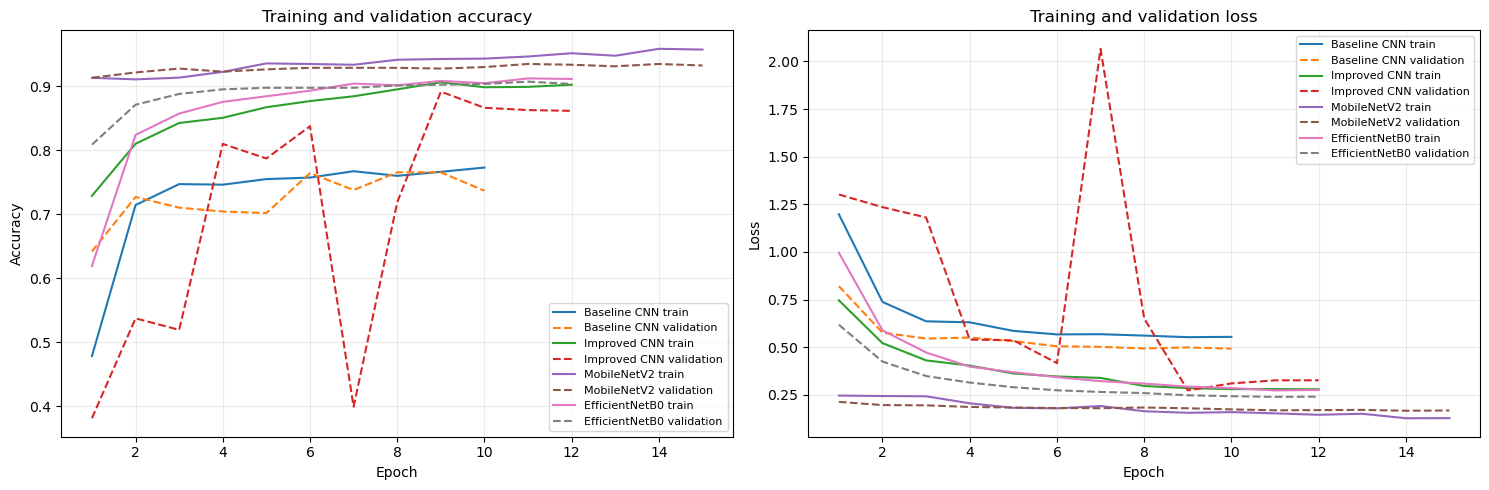

In [33]:
histories = {
    "Baseline CNN": baseline_history,
    "Improved CNN": improved_history,
    "MobileNetV2": mobilenet_history,
    "EfficientNetB0": efficientnet_history,
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for model_name, history in histories.items():
    epoch_numbers = range(1, len(history.history["accuracy"]) + 1)
    axes[0].plot(epoch_numbers, history.history["accuracy"], label=f"{model_name} train")
    axes[0].plot(epoch_numbers, history.history["val_accuracy"], linestyle="--", label=f"{model_name} validation")
    axes[1].plot(epoch_numbers, history.history["loss"], label=f"{model_name} train")
    axes[1].plot(epoch_numbers, history.history["val_loss"], linestyle="--", label=f"{model_name} validation")

axes[0].set_title("Training and validation accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[1].set_title("Training and validation loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Model evaluation and comparison

Compare accuracy, macro precision, macro recall, macro F1, and parameter count on the untouched validation set.

In [34]:
# 6.1 Evaluate every candidate model
model_registry = {
    "Baseline CNN": (baseline_cnn, baseline_history),
    "Improved CNN": (improved_cnn, improved_history),
    "MobileNetV2": (mobilenet_v2, mobilenet_history),
    "EfficientNetB0": (efficientnet_b0, efficientnet_history),
}

validation_true = validation_df["label_id"].to_numpy()
evaluation_rows = []
per_class_rows = []
prediction_cache = {}

for model_name, (trained_model, history) in model_registry.items():
    probabilities = trained_model.predict(validation_ds, verbose=0)
    predictions = probabilities.argmax(axis=1)
    prediction_cache[model_name] = predictions
    report = classification_report(
        validation_true,
        predictions,
        labels=list(range(num_classes)),
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    evaluation_rows.append({
        "model": model_name,
        "accuracy": report["accuracy"],
        "macro_precision": report["macro avg"]["precision"],
        "macro_recall": report["macro avg"]["recall"],
        "macro_f1": report["macro avg"]["f1-score"],
        "best_val_accuracy": max(history.history["val_accuracy"]),
        "parameters": trained_model.count_params(),
    })
    for class_name in class_names:
        per_class_rows.append({
            "model": model_name,
            "class": class_name,
            "precision": report[class_name]["precision"],
            "recall": report[class_name]["recall"],
            "f1": report[class_name]["f1-score"],
            "support": report[class_name]["support"],
        })

evaluation_df = pd.DataFrame(evaluation_rows).sort_values("macro_f1", ascending=False)
per_class_metrics_df = pd.DataFrame(per_class_rows)
print("Overall validation comparison:")
display(evaluation_df.round(4))
print("Per-class metrics:")
display(per_class_metrics_df.round(4))

Overall validation comparison:


,model,accuracy,macro_precision,macro_recall,macro_f1,best_val_accuracy,parameters
2,MobileNetV2,0.9351,0.9215,0.9165,0.9188,0.9351,2263108
3,EfficientNetB0,0.9075,0.8918,0.8687,0.8764,0.9075,4054695
1,Improved CNN,0.8918,0.8678,0.8839,0.8701,0.8918,110948
0,Baseline CNN,0.7368,0.7038,0.7153,0.6801,0.7656,23812


Per-class metrics:


,model,class,precision,recall,f1,support
0,Baseline CNN,Blight,0.6327,0.2731,0.3815,227.0
1,Baseline CNN,Common_Rust,0.8690,0.9692,0.9164,260.0
2,Baseline CNN,Gray_Leaf_Spot,0.3476,0.6404,0.4506,114.0
3,Baseline CNN,Healthy,0.9658,0.9784,0.9720,231.0
4,Improved CNN,Blight,0.8919,0.7269,0.8010,227.0
5,Improved CNN,Common_Rust,0.9540,0.9577,0.9559,260.0
6,Improved CNN,Gray_Leaf_Spot,0.6424,0.8509,0.7321,114.0
7,Improved CNN,Healthy,0.9830,1.0000,0.9914,231.0
8,MobileNetV2,Blight,0.8831,0.8987,0.8908,227.0
9,MobileNetV2,Common_Rust,0.9730,0.9692,0.9711,260.0


## 6.2 Confusion matrices

Plot a confusion matrix for every candidate model using the same validation labels.

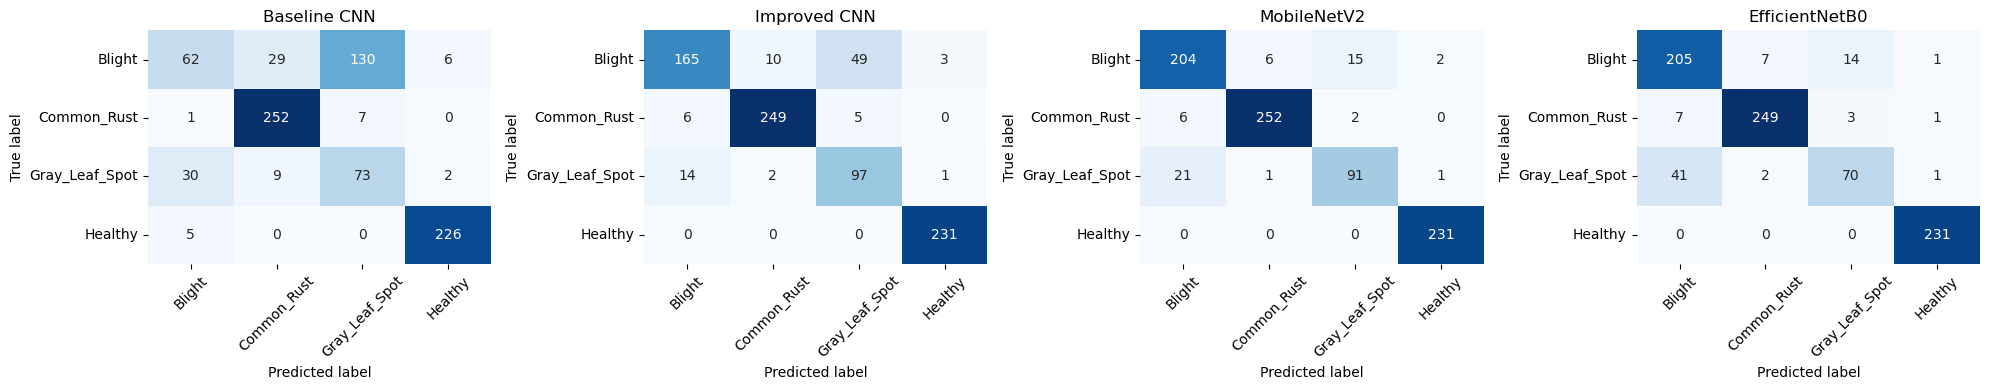

In [35]:
# 6.2 Confusion matrices for all candidate models
fig, axes = plt.subplots(1, len(model_registry), figsize=(5 * len(model_registry), 4))
axes = np.atleast_1d(axes).ravel()

for axis, (model_name, predictions) in zip(axes, prediction_cache.items()):
    matrix = confusion_matrix(validation_true, predictions, labels=list(range(num_classes)))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axis,
    )
    axis.set_title(model_name)
    axis.set_xlabel("Predicted label")
    axis.set_ylabel("True label")
    axis.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 6.3 Select and save the best model

Select by validation macro F1 so every class contributes equally, then save the complete Keras model.

In [36]:
# 6.3 Save the best model selected by validation macro F1
best_model_name = evaluation_df.iloc[0]["model"]
best_model = model_registry[best_model_name][0]
artifact_dir = Path("artifacts")
artifact_dir.mkdir(exist_ok=True)
best_model_path = artifact_dir / "best_corn_leaf_model.keras"
best_model.save(best_model_path)

print(f"Best model by validation macro F1: {best_model_name}")
print(f"Best model parameters: {best_model.count_params():,}")
print(f"Saved to: {best_model_path}")

Best model by validation macro F1: MobileNetV2
Best model parameters: 2,263,108
Saved to: artifacts\best_corn_leaf_model.keras
